# Imports

In [ ]:
# Standard Library Imports
from abc import ABC, abstractmethod
import os
import time
from typing import List

# Data Processing & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

# Machine Learning & NLP
from datasets import load_dataset
import torch
import fasttext
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib



In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using runtime execution target: {device.upper()}")
if device == "cuda":
    print(f"GPU Name:     {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info()
    print(f"Total Memory: {total / 1024**3:.2f} GB")
    print(f"Free Memory:  {free / 1024**3:.2f} GB")

Using runtime execution target: CPU


# Data Preprocessing

In [33]:
# 1. Load the specific dataset from Hugging Face Hub
dataset_dict = load_dataset("papluca/language-identification")

# 2. Map structural Arrow splits cleanly into Pandas DataFrames
train_df = dataset_dict['train'].to_pandas()
val_df = dataset_dict['validation'].to_pandas()
test_df = dataset_dict['test'].to_pandas()

In [34]:
print(f"Ingestion successful!\nTrain Rows: {len(train_df)} | Val Rows: {len(val_df)} | Test Rows: {len(test_df)}")

Ingestion successful!
Train Rows: 70000 | Val Rows: 10000 | Test Rows: 10000


In [35]:
train_df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [36]:
lang_map = {
    'ar': 'Arabic', 'bg': 'Bulgarian', 'de': 'German', 'el': 'Modern Greek',
    'en': 'English', 'es': 'Spanish', 'fr': 'French', 'hi': 'Hindi',
    'it': 'Italian', 'ja': 'Japanese', 'nl': 'Dutch', 'pl': 'Polish',
    'pt': 'Portuguese', 'ru': 'Russian', 'sw': 'Swahili', 'th': 'Thai',
    'tr': 'Turkish', 'ur': 'Urdu', 'vi': 'Vietnamese', 'zh': 'Chinese'
}

train_df['language_name'] = train_df['labels'].map(lang_map)

In [37]:
train_df.head()

,labels,text,language_name
0,pt,"os chefes de defesa da estónia, letónia, lituâ...",Portuguese
1,bg,размерът на хоризонталната мрежа може да бъде ...,Bulgarian
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,Chinese
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,Thai
4,ru,Он увеличил давление .,Russian


In [38]:
counts_per_label = train_df.groupby('language_name').size().sort_values(ascending=False)

print("Counts per Label:")
print(counts_per_label)

Counts per Label:
language_name
Arabic          3500
Bulgarian       3500
Chinese         3500
Dutch           3500
English         3500
French          3500
German          3500
Hindi           3500
Italian         3500
Japanese        3500
Modern Greek    3500
Polish          3500
Portuguese      3500
Russian         3500
Spanish         3500
Swahili         3500
Thai            3500
Turkish         3500
Urdu            3500
Vietnamese      3500
dtype: int64


<font color='lightgreen'>Note: </font> Dataset is balanced

In [39]:
train_df.describe().T

,count,unique,top,freq
labels,70000,20,pt,3500
text,70000,68978,Een man speelt gitaar.,18
language_name,70000,20,Portuguese,3500


<font color='lightgreen'>Note: </font> There are duplicates in the text

In [40]:
train_df['text'].duplicated().sum()

np.int64(1022)

In [41]:
train_df.duplicated().sum()

np.int64(1020)

In [42]:
multi_labels_text = train_df[train_df['text'].duplicated() != train_df.duplicated()]['text']

In [43]:
train_df[train_df['text'].isin(multi_labels_text.to_list())]

,labels,text,language_name
5551,pl,Snowden Hits Hurdles in Search for Asylum,Polish
20561,nl,Snowden Hits Hurdles in Search for Asylum,Dutch
51539,pt,Santorum Romping To Minnesota Victory,Portuguese
53666,nl,Santorum Romping To Minnesota Victory,Dutch


<font color='lightgreen'>Note: </font> Found 2 instances of more than one label.

In [44]:
train_df[train_df.duplicated()].value_counts()

labels  text                                                         language_name
nl      Een man speelt gitaar.                                       Dutch            17
pt      Um homem está a tocar guitarra.                              Portuguese       17
it      Un uomo sta suonando una chitarra.                           Italian          10
pl      Człowiek gra na gitarze.                                     Polish           10
        Mężczyzna gra na gitarze.                                    Polish            6
                                                                                      ..
nl      Het legt geen moraal op.                                     Dutch             1
        Het zou niet stoppen met grapjeshuwelijken.                  Dutch             1
        Hoe lang na de verwoesting moet het kind terug naar school?  Dutch             1
        I. ATLANTISHE EISEN .                                        Dutch             1
        Een zwart-witte gehoornde koe die in de wei staat.           Dutch             1
Name: count, Length: 827, dtype: int64

In [45]:
# Count the total number of duplicate rows for every label
duplicate_counts_per_label = train_df[train_df.duplicated()].groupby('language_name')\
                             .size().sort_values(ascending=False)

print("Duplicate Counts per Label:")
print(duplicate_counts_per_label)


Duplicate Counts per Label:
language_name
Polish          166
Dutch           160
Italian         154
Portuguese      150
Urdu             44
Russian          37
Swahili          37
Thai             37
Modern Greek     37
Arabic           36
Bulgarian        36
Vietnamese       36
Turkish          36
Hindi            36
Chinese           9
French            5
Spanish           2
English           1
German            1
dtype: int64


/tmp/ipykernel_4808/754026684.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


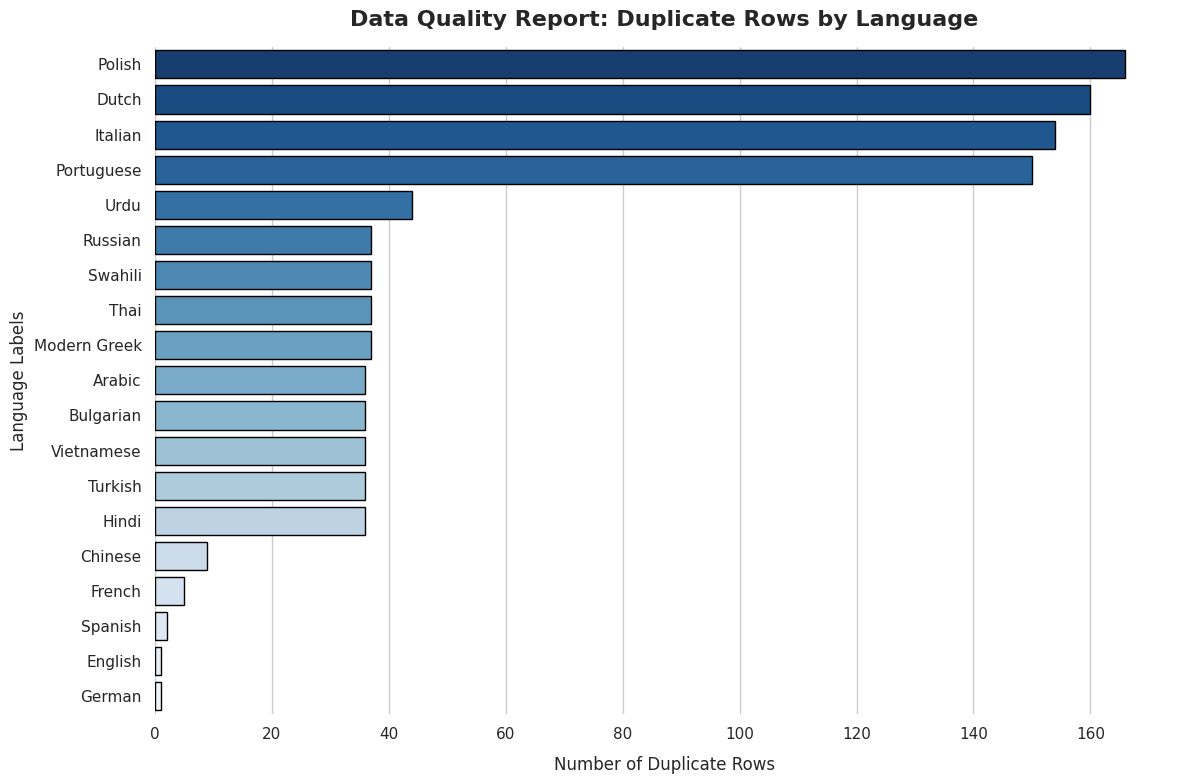

In [46]:
# Plot using a sequential color palette (darkest = most duplicates)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=duplicate_counts_per_label.values,
    y=duplicate_counts_per_label.index,
    palette="Blues_r",
    edgecolor="black"
)

plt.title('Data Quality Report: Duplicate Rows by Language', fontsize=16, pad=15, weight='bold')
plt.xlabel('Number of Duplicate Rows', fontsize=12, labelpad=10)
plt.ylabel('Language Labels', fontsize=12)

# Remove the unnecessary outer box lines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


<font color='lightgreen'>Note: </font> Dataset not balanced 😞

In [47]:
unique_train_df = train_df.drop_duplicates(subset='text', keep='first')
unique_train_df.head()

,labels,text,language_name
0,pt,"os chefes de defesa da estónia, letónia, lituâ...",Portuguese
1,bg,размерът на хоризонталната мрежа може да бъде ...,Bulgarian
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,Chinese
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,Thai
4,ru,Он увеличил давление .,Russian


In [48]:
unique_train_df.describe().T

,count,unique,top,freq
labels,68978,20,ja,3500
text,68978,68978,कोसोवो कथा का विवरण जिसमें स ् थानीय राष ् ट ्...,1
language_name,68978,20,Japanese,3500


/tmp/ipykernel_4808/3847616053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


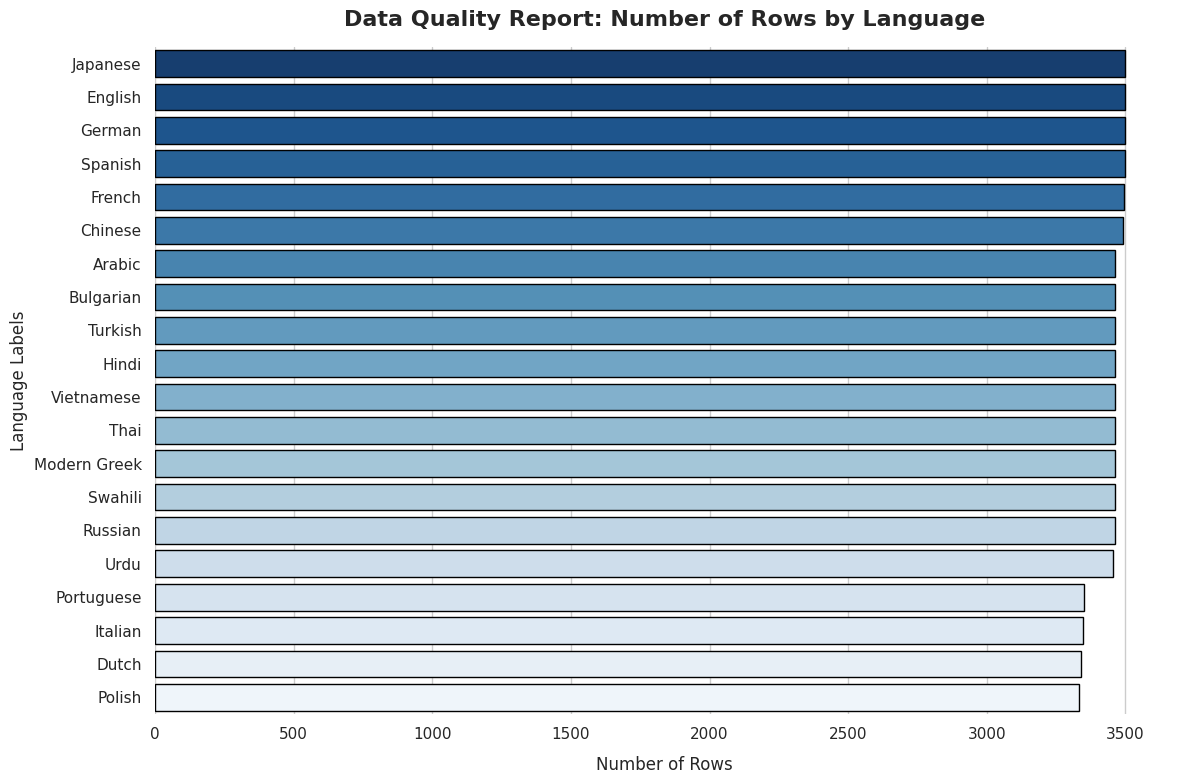

In [49]:
counts_per_label = unique_train_df.groupby('language_name').size()\
                   .sort_values(ascending=False)

# Plot using a sequential color palette (darkest = most freq)
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=counts_per_label.values,
    y=counts_per_label.index,
    palette="Blues_r",
    edgecolor="black"
)

plt.title('Data Quality Report: Number of Rows by Language',
          fontsize=16, pad=15, weight='bold')
plt.xlabel('Number of Rows', fontsize=12, labelpad=10)
plt.ylabel('Language Labels', fontsize=12)

# Remove the unnecessary outer box lines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


# Experiments

In [50]:
class BaseLanguageDetector(ABC):
    """
    Abstract contract ensuring uniform signatures across Traditional ML,
    Static Embeddings, and Contextual Deep Learning architectures.
    """
    @abstractmethod
    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame) -> None:
        """Train the underlying model using a consistent dataframe schema."""
        pass

    @abstractmethod
    def predict(self, text: str) -> str:
        """Infer the single language ISO code for a standalone user query."""
        pass

    def calculate_inference_latency(self, sample_texts: List[str]) -> float:
        """Calculates average inference duration per isolated query (in milliseconds)."""
        start_time = time.perf_counter()
        for text in sample_texts:
            _ = self.predict(text)
        end_time = time.perf_counter()
        return ((end_time - start_time) / len(sample_texts)) * 1000

## TF-IDF + SAGA LogReg

In [51]:
class TraditionalMLDetector(BaseLanguageDetector):
    def __init__(self):
        self.pipeline = Pipeline([
            ('vectorizer', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=50000)),
            ('classifier', LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1))
        ])

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame) -> None:
        print("--- Training TF-IDF + Logistic Regression Baseline ---")
        self.pipeline.fit(train_df['text'], train_df['labels'])
        print("--- Model training completed successfully. ---")

    def predict(self, text: str) -> str:
        return str(self.pipeline.predict([text])[0])

## FastText

In [52]:
class FastTextDetector(BaseLanguageDetector):
    def __init__(self, model_path: str = "fasttext_lang_model.bin"):
        self.model_path = model_path
        self.model = None

    def _prepare_file(self, df: pd.DataFrame, output_path: str) -> None:
        """
        Defensively writes data to disk.
        """
        with open(output_path, 'w', encoding='utf-8') as f:
            for _, row in df.iterrows():
                # 1. Ensure we don't process NaN/Null values as floats
                text_val = str(row['text']) if pd.notna(row['text']) else ""
                label_val = str(row['labels']) if pd.notna(row['labels']) else ""

                # 2. Crucial: Strip ALL internal newlines, carriage returns, and tabs
                clean_text = text_val.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
                clean_text = clean_text.strip()

                # 3. Skip completely empty text rows to prevent zero-token C++ crashes
                if not clean_text or not label_val:
                    continue

                # 4. Use the strict, default FastText standard prefix: __label__
                f.write(f"__label___{label_val} {clean_text}\n")

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame) -> None:
        print("--- Training Meta FastText Baseline ---")
        tmp_train = "tmp_fasttext_train.txt"

        # Build the structured file
        self._prepare_file(train_df, tmp_train)

        # Verify the file was created and isn't empty
        if not os.path.exists(tmp_train) or os.path.getsize(tmp_train) == 0:
            raise RuntimeError("FastText training file is empty or was not created correctly.")

        try:
            self.model = fasttext.train_supervised(
                input=tmp_train,
                epoch=10,
                lr=0.2,
                wordNgrams=2,
                dim=100,
                loss='softmax'
            )
            print("FastText training completed successfully!")
        except Exception as e:
            print(f"An error occurred during FastText execution: {e}")
        finally:
            # Always clean up the temporary file
            if os.path.exists(tmp_train):
                os.remove(tmp_train)

    def predict(self, text: str) -> str:
        if self.model is None:
            raise ValueError("Model has not been trained yet.")

        # Clean text format exactly like training data input
        clean_text = str(text).replace('\n', ' ').replace('\r', ' ').replace('\t', ' ').strip()
        if not clean_text:
            return "unknown"

        predictions = self.model.predict([clean_text], k=1)
        return predictions[0][0][0].replace("__label___", "")

In [53]:
# Benchmark Execution:
def run_system_benchmark(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    models = {
        "Traditional_ML (TF-IDF + SAGA LogReg)": TraditionalMLDetector(),
        "Statistical_SOTA (Meta FastText)": FastTextDetector()
    }

    performance_matrix = {}

    for name, model in models.items():
        # Train
        model.fit(train_df, val_df)

        # Infer predictions across test dataset
        print(f"Running inference benchmarking for {name}...")
        predictions = [model.predict(text) for text in test_df['text']]

        # Calculate evaluation parameters
        acc = accuracy_score(test_df['labels'], predictions)
        latency = model.calculate_inference_latency(test_df['text'].head(100).tolist())

        performance_matrix[name] = {
            "Accuracy": f"{acc * 100:.2f}%",
            "Avg Inference Latency (per query)": f"{latency:.3f} ms"
        }

        print(f"\nClassification Report for {name}:\n")
        print(classification_report(test_df['labels'], predictions))
        print("="*60)

    return pd.DataFrame(performance_matrix).T

In [54]:
benchmark_summary_table = run_system_benchmark(unique_train_df, val_df, test_df)
display(benchmark_summary_table)

--- Training TF-IDF + Logistic Regression Baseline ---
--- Model training completed successfully. ---
Running inference benchmarking for Traditional_ML (TF-IDF + SAGA LogReg)...

Classification Report for Traditional_ML (TF-IDF + SAGA LogReg):

              precision    recall  f1-score   support

          ar       1.00      0.98      0.99       500
          bg       0.99      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.95      0.98       500
          it       1.00      0.99      0.99       500
          ja       1.00      0.99      0.99       500
          nl       1.00      0.99      0.99       500
          pl       1.00      1.00      1.00       500
          pt       0.99      0.98      0.99       50

,Accuracy,Avg Inference Latency (per query)
Traditional_ML (TF-IDF + SAGA LogReg),99.05%,2.820 ms
Statistical_SOTA (Meta FastText),86.41%,0.028 ms


# Final Language Detector Model

In [55]:
class LanguageDetector:
    def __init__(self):
        # Bundling preprocessing and classification together
        self.pipeline = Pipeline([
            ('vectorizer', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=50000)),
            ('classifier', LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1))
        ])

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame = None) -> None:
        print("--- Training TF-IDF + Logistic Regression pipeline ---")

        # Train on the training split
        self.pipeline.fit(train_df['text'], train_df['labels'])
        print("--- Model training completed successfully. ---")

        # Utilize val_df for immediate quality control tracking if provided
        if val_df is not None:
            val_preds = self.pipeline.predict(val_df['text'])
            val_acc = accuracy_score(val_df['labels'], val_preds)
            print(f"--> Immediate Validation Accuracy: {val_acc * 100:.2f}%")

    def predict(self, text: str) -> str:
        if not hasattr(self.pipeline, "classes_"):
            raise ValueError("The model pipeline must be fitted before running predictions.")
        return str(self.pipeline.predict([text])[0])

    def save_model(self, file_path: str = "language_detector.pkl"):
        """Exports the complete fitted pipeline to disk."""
        joblib.dump(self.pipeline, file_path, compress=3)
        print(f"Pipeline saved securely at: {file_path}")

    def load_model(self, file_path: str = "language_detector.pkl"):
        """Imports an exported pipeline file directly into the instance state."""
        self.pipeline = joblib.load(file_path)
        print(f"Pipeline loaded successfully from: {file_path}")

In [56]:
# --- Final Model Execution ---
detector = LanguageDetector()
detector.fit(unique_train_df, val_df)
detector.save_model("language_detector.pkl")

--- Training TF-IDF + Logistic Regression pipeline ---
--- Model training completed successfully. ---
--> Immediate Validation Accuracy: 99.16%
Pipeline saved securely at: language_detector.pkl
